In [19]:
import json
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

In [76]:
data_path = r"C:\Users\leroquan\Documents\Data\meteo\stations meteo\Pully\2023.json"

date_start_01 = np.datetime64("2023-09-02 12:30")
date_end_01 = np.datetime64("2023-09-12 12:30")

date_start_02 = np.datetime64("2023-10-29 14:00")
date_end_02 = np.datetime64("2023-11-08 15:00")

In [77]:
with open(data_path, "r", encoding="utf-8") as file:
    input_data = json.load(file)  # Load JSON into a Python object

In [78]:
# Extract data
times = input_data["time"]
wind_speeds = input_data["variables"]["wind_speed"]["data"]
wind_directions = input_data["variables"]["wind_direction"]["data"]

# Build a list of rows
rows = []
for t, ws, wd in zip(times, wind_speeds, wind_directions):
    dt = datetime.fromisoformat(t.replace("Z", "+00:00"))
    rows.append([
        dt,
        ws,
        wd
    ])

# Create DataFrame
df = pd.DataFrame(rows, columns=["time", "Wind", "Direction"])
df['time'] = df['time'].dt.tz_convert(None)  # removes timezone

In [79]:
df_crop_01 = df[(df['time'] > date_start_01) & (df['time'] < date_end_01)]
df_crop_02 = df[(df['time'] > date_start_02) & (df['time'] < date_end_02)]

In [80]:
hours_before_sampling = np.sort(-1*np.array(range(len(df_crop_01["time"]))))

In [81]:
len(df_crop_02["Wind"])

240

Text(0, 0.5, 'Wind Speed (m/s)')

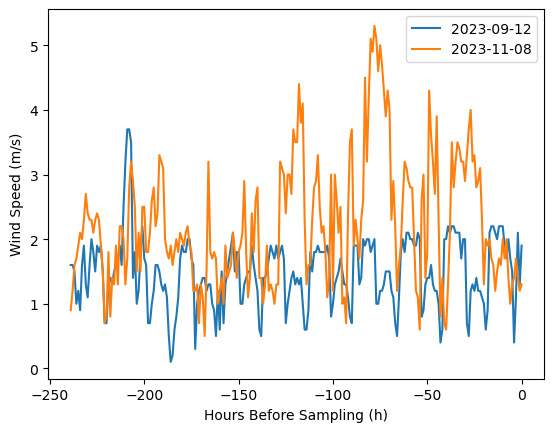

In [84]:
plt.plot(hours_before_sampling, df_crop_01["Wind"], label="2023-09-12")
plt.plot(hours_before_sampling, df_crop_02["Wind"], label="2023-11-08")
plt.legend()
plt.xlabel("Hours Before Sampling (h)")
plt.ylabel("Wind Speed (m/s)")